In [2]:
import pandas as pd
df = pd.read_csv("modeling_tables/clustering.csv")
pca_df = pd.read_csv("pca_5components.csv")

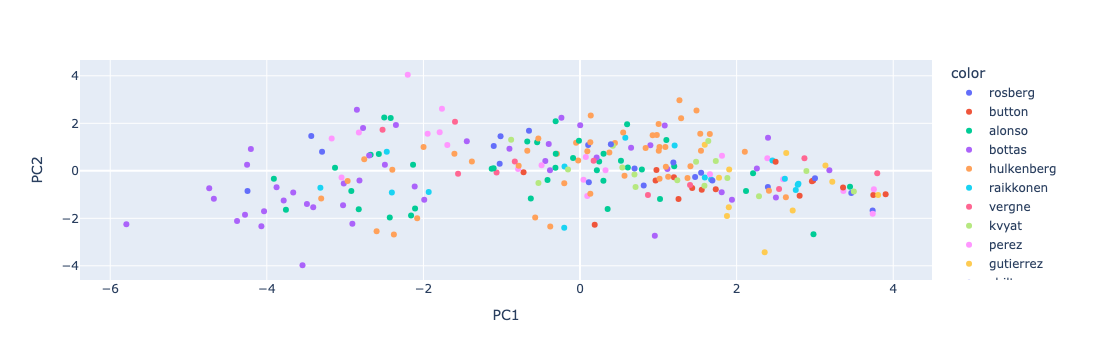

In [97]:
import plotly.express as px
import plotly.io as pio

# PC1 vs PC2
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color=df['ref'],  #color by driver
    hover_data=[df["total_points"],df['logit_dnf'], df['logit_top10'], df['avg_finish'], df['ref'], df['year'],df['constructorRef']]
)
fig.show()


html_snippet = pio.to_html(fig, full_html=False, include_plotlyjs='cdn')

with open("pca_plot_snippet.html", "w") as f:
    f.write(html_snippet)

The PCA visualization suggests that driver performance does not form clearly separated groups but instead lies along a continuous spectrum. In the PC1–PC2 space, observations are distributed smoothly across the plot rather than forming isolated clusters. This pattern indicates that differences in driver performance are gradual rather than categorical: drivers transition progressively from highly competitive seasons to weaker ones, rather than belonging to sharply defined types. This is consistent with the nature of Formula 1 performance, where outcomes are influenced by a combination of driver skill, team strength, reliability, and race variability. As a result, the underlying structure of the dataset appears closer to a performance gradient than to a set of naturally separated clusters.

Despite this continuous structure, clustering remains useful as a tool for segmenting the performance spectrum into interpretable regions. Rather than discovering completely distinct groups, the objective of clustering in this project is to identify driver archetypes or performance tiers that summarize common patterns across driver-season observations. By grouping observations that share similar PCA characteristics, clustering allows the dataset to be organized into a small number of representative profiles—such as elite consistent performers, competitive midfield drivers, or high-variance backmarkers. This segmentation simplifies the interpretation of the multidimensional performance data and provides a structured way to analyze how drivers distribute across different performance archetypes throughout the seasons.

In [4]:
pca_df

,PC1,PC2,PC3,PC4,PC5
0,-3.294588,0.800184,-2.350029,-0.277565,-1.751753
1,-0.721154,-0.059846,0.167013,0.104003,-1.282462
2,-2.157575,-1.882681,0.756466,0.413482,-1.088611
3,-2.111360,-0.658992,0.087204,-0.222249,-1.334535
4,-0.572523,-1.961747,-0.212717,-1.139627,0.216350
...,...,...,...,...,...
238,1.405383,-0.597282,0.213710,-0.092247,-0.593282
239,0.300339,0.721427,-0.383953,-0.544635,1.196136
240,1.487332,2.537156,2.340866,-0.468203,0.268529
241,0.394231,1.117277,0.814690,-1.252195,1.219256


## K-Means

### Elbow method

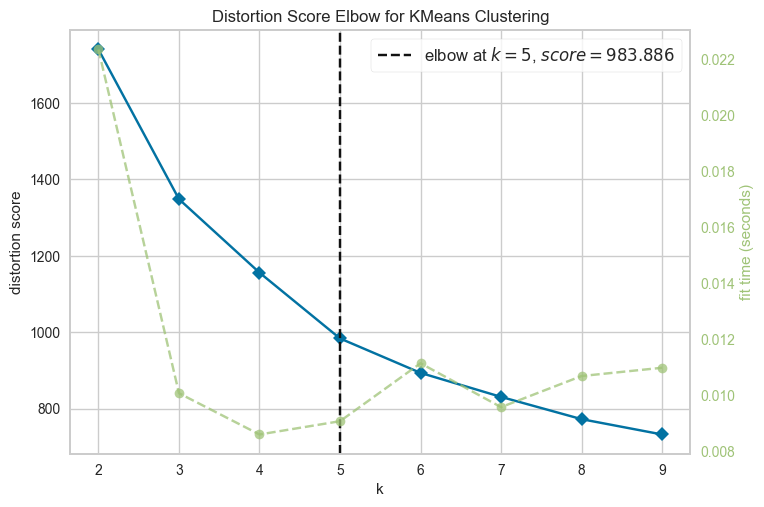

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [100]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

#Elbow method for choosing K
km = KMeans(n_clusters=4, n_init=20, random_state=42)

visualizer = KElbowVisualizer(
    km,
    k=(2,10),
    force_model=True
)

visualizer.fit(pca_df)
plt.savefig(f"images/analysis/elbow.png", bbox_inches="tight", dpi=150)
visualizer.show()

### Silhouette score Davies–Bouldin Index, and  Calinski–Harabasz Index.

To decide how many clusters to use, I looked at silhouette scores, the Davies–Bouldin Index, and the Calinski–Harabasz Index. The silhouette scores slowly decrease as K increases (K=2: 0.344, K=3: 0.247, K=4: 0.230, K=5: 0.218). That’s actually pretty normal here because driver performance doesn’t fall into perfectly separate groups—it’s more of a continuous gradient from bad seasons to great seasons. Looking at the silhouette plots, the clusters also look a bit more balanced in size for K=4 compared to K=5, meaning the four clusters are distributed a little more evenly. That said, the difference in silhouette score between K=4 and K=5 is pretty small (0.230 vs 0.218), so adding another cluster doesn’t really hurt the overall clustering quality much.

When we bring in the other metrics, things get a bit more interesting. The Davies–Bouldin score drops from 1.582 with K=4 to 1.428 with K=5, which is about a 10% improvement. Since lower values are better for this metric, that suggests the clusters are less similar to each other when we use five clusters. The Calinski–Harabasz score does go down slightly (86.94 → 84.45), but the change is small and doesn’t outweigh the improvement in Davies–Bouldin. From a Formula 1 perspective, this also makes sense. Driver seasons tend to fall into performance tiers—like dominant championship seasons, strong competitive seasons, solid midfield years, struggling seasons, and true backmarker performances. Using five clusters helps separate these types a bit more clearly, instead of lumping nearby performance levels together like the four-cluster solution might. So even though K=4 looks a bit nicer in the silhouette plots, the better separation and the more realistic performance tiers make K=5 the better choice overall.

K = 2, Silhouette score = 0.344
K = 3, Silhouette score = 0.247
K = 4, Silhouette score = 0.230
K = 5, Silhouette score = 0.218


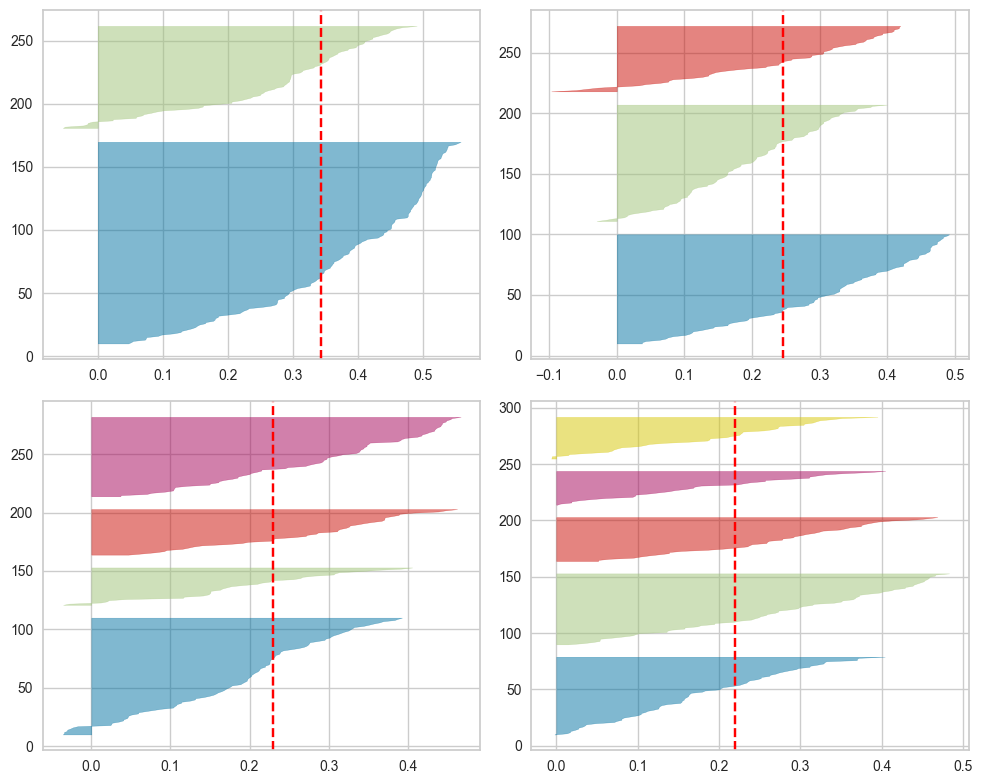

In [8]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

#Silhouette score across k
for k in range(2, 6):
    
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = kmeans.fit_predict(pca_df)
    
    score = silhouette_score(pca_df, labels)
    
    print(f"K = {k}, Silhouette score = {score:.3f}")

X = pca_df.values 

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

for i in [2, 3, 4, 5]:
    
    km = KMeans(
        n_clusters=i,
        init='k-means++',
        n_init=10,
        max_iter=100,
        random_state=42
    )
    
    q, mod = divmod(i, 2)
    
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod], force_model=True)
    visualizer.fit(X)  
    
plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

for k in [4,5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_df)

    db_score = davies_bouldin_score(pca_df, labels)
    ch_score = calinski_harabasz_score(pca_df, labels)

    print(f"k={k}\nDavies–Bouldin Index score = {db_score:.4f}\nCalinski–Harabasz Index score = {ch_score:.4f}")

k=4
Davies–Bouldin Index score = 1.5820
Calinski–Harabasz Index score = 86.9411
k=5
Davies–Bouldin Index score = 1.4285
Calinski–Harabasz Index score = 84.4475


In [104]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#Plot clusters on PC1 vs PC2 with driver names + season year.
def plot_cluster(pca_df, original_df, labels, centroids, k):
    
    # Prepare plotting dataframe
    plot_df = pca_df.copy()
    plot_df['driver_name'] = original_df['ref'].values
    plot_df['year'] = original_df['year'].values
    plot_df['cluster'] = labels
    
    # Generate colors dynamically in case k != 4
    cmap = plt.get_cmap('Set2')
    colors = [cmap(i) for i in range(k)]
    
    # Plot each cluster
    for i, cluster_id in enumerate(range(k)):
        cluster_points = plot_df[plot_df['cluster'] == cluster_id]
        plt.scatter(
            cluster_points['PC1'], cluster_points['PC2'],
            s=60, alpha=0.7, c=[colors[i]],
            label=f'Cluster {cluster_id}'
        )
        
        # Annotate 4 representative drivers per cluster (spread across PC1)
        quartiles = np.quantile(cluster_points['PC1'], [0.0, 0.25, 0.5, 0.75, 1.0])
        for q in range(4):
            lower, upper = quartiles[q], quartiles[q+1]
            candidates = cluster_points[(cluster_points['PC1'] >= lower) & (cluster_points['PC1'] <= upper)].copy()
            if len(candidates) > 0:
                pc2_median = candidates['PC2'].median()
                candidates['dist_to_median'] = np.abs(candidates['PC2'] - pc2_median)
                best_driver = candidates.loc[candidates['dist_to_median'].idxmin()]
                plt.text(best_driver['PC1'] + 0.02, best_driver['PC2'],
                         f"{best_driver['driver_name']} {int(best_driver['year'])}",
                         fontsize=9, weight='bold')
    
    # Plot centroids as black X
    plt.scatter(
        centroids[:, 0], centroids[:, 1],
        c='black', s=200, marker='X'
    )
    
    plt.title(f'{k}-Means Clusters in PCA Space (PC1 vs PC2)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(title='Clusters', loc='upper right')
    plt.savefig(f"images/analysis/{k}k_space.png", bbox_inches="tight", dpi=150)
    plt.show()

### Clusters in PCA space

In [105]:
four_means = KMeans(n_clusters=4, n_init=20, random_state=42).fit(pca_df)
five_means = KMeans(n_clusters=5, n_init=20, random_state=42).fit(pca_df)

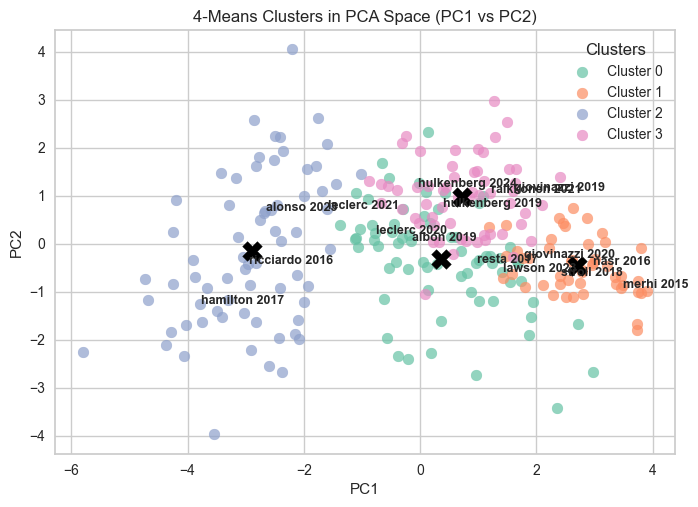

In [111]:
plot_cluster(pca_df, df, four_means.labels_, four_means.cluster_centers_, 4)

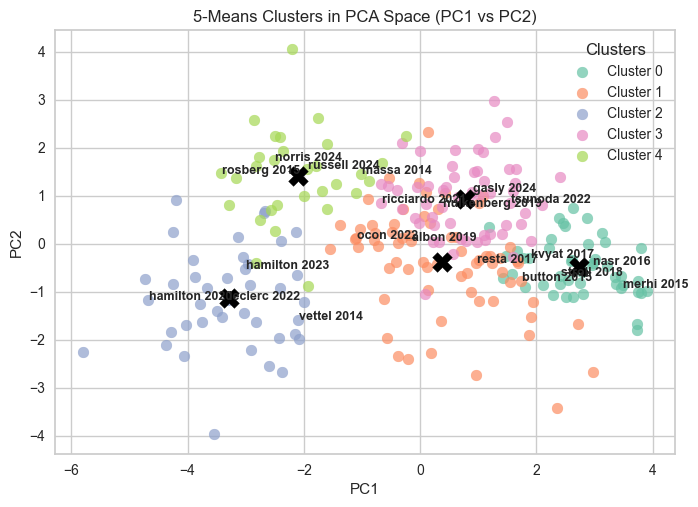

In [109]:
plot_cluster(pca_df, df, five_means.labels_, five_means.cluster_centers_, 5)

### GMM

k = 1 BIC Score 4812.949383692599
k = 2 BIC Score 4220.439370359875
k = 3 BIC Score 3130.368362197808
k = 4 BIC Score 1949.7125576729768
k = 5 BIC Score 1338.6031030849267
k = 6 BIC Score 1441.0039380424987
k = 7 BIC Score 1424.7781021145233
k = 8 BIC Score 1638.1828518483167
k = 9 BIC Score 1753.4057067467324


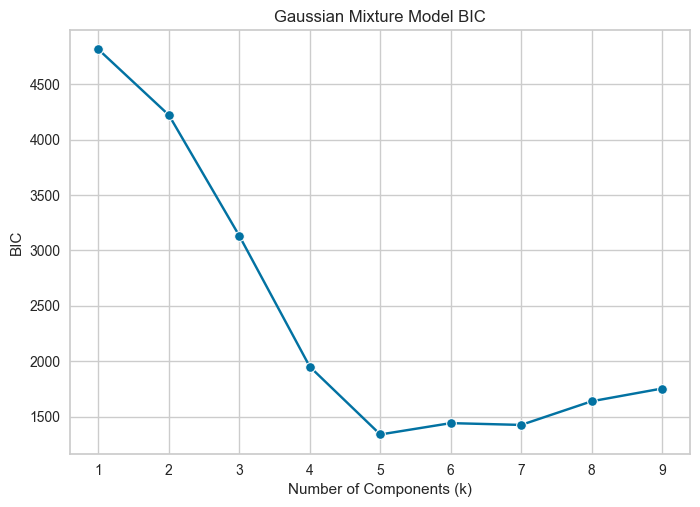

In [110]:
from sklearn.mixture import GaussianMixture
import seaborn as sns

bic = []
for k in range(1,10):
    gm = GaussianMixture(n_components=k, random_state=42).fit(pca_df)
    bic.append(gm.bic(pca_df))
    print(f"k = {k} BIC Score {gm.bic(pca_df)}")


sns.lineplot(x=range(1,10), y=bic, marker='o')
plt.xlabel("Number of Components (k)")
plt.ylabel("BIC")
plt.title("Gaussian Mixture Model BIC")
plt.savefig(f"images/analysis/gmm_bic.png", bbox_inches="tight", dpi=150)
plt.show()

I also tried a Gaussian Mixture Model and evaluated it using the Bayesian Information Criterion. The lowest BIC score showed up at K = 2, which basically means that from a purely statistical point of view the data could be explained by two broad distributions. In other words, the model mostly sees something like a split between strong seasons and weaker seasons.

But when we look at the results through a Formula 1 lens, two clusters is way too simple to describe what’s actually going on. In reality, driver seasons tend to fall into several recognizable performance tiers: dominant championship-level seasons, very strong contender seasons, solid midfield consistency, struggling seasons, and true backmarker performances. The earlier K-Means Clustering analysis suggested that somewhere between four and five clusters captured these tiers best. Even if the Gaussian mixture model sees two broad statistical groups, splitting the gradient further makes the results much more interpretable in a racing context. With five clusters, the model can separate subtle differences—like distinguishing a driver who consistently finishes P6–P8 from someone stuck fighting for P12 every weekend. Because of that, the five-cluster solution ends up being more meaningful for understanding driver-season archetypes, even if the underlying data can technically be approximated by fewer probabilistic distributions.

In [24]:
gmm = GaussianMixture(n_components=5)
gmm.fit(pca_df)

,"n_components n_components: int, default=1The number of mixture components.",5
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [26]:
probs = gmm.predict_proba(pca_df)
prob_cols = [f"Cluster {i}" for i in range(5)]
df[prob_cols] = probs
df[prob_cols] = df[prob_cols] * 100

In [27]:
df["gmm_cluster"] = df[prob_cols].idxmax(axis=1)

df["gmm_cluster"] = df["gmm_cluster"].str.extract("(\d)").astype(int)

### Clusters summary
Looking at the average statistics for each cluster, the groups form a pretty clear performance ladder across driver-seasons. Cluster 1 stands out as the strongest group by a wide margin, with an average of about 263 points, an average finish around 3.6, and an almost perfect top-10 rate of 99%, while DNFs stay relatively low at about 13%. These are clearly the dominant or championship-level seasons where drivers are finishing near the front almost every race. Cluster 2 looks like the next tier down: still very strong with about 198 points, an average finish around 5.2, and 88% top-10 finishes, but not quite as dominant as Cluster 1. Cluster 0 represents a more typical midfield performance with around 69 points, an average finish near 9th, and a 62% top-10 rate, though the DNF rate jumps up to almost 48%, suggesting more inconsistency. From there the performance drops off quite a bit. Cluster 3 captures struggling or lower-midfield seasons, averaging only 29 points, finishing around 11.5 on average, and with DNFs above 60%. Finally, Cluster 4 clearly represents backmarker seasons, with only about 4 points on average, very poor finishing positions (~14.8 average finish), extremely low top-10 appearances (~8%), and an extremely high DNF rate of about 85%, showing just how difficult those seasons tend to be.

In [40]:
cluster_summary = df.groupby("gmm_cluster")[["total_points","avg_finish","top10","DNF_rate", "finish_volatility"]].mean()
print(cluster_summary)

             total_points  avg_finish     top10  DNF_rate  finish_volatility
gmm_cluster                                                                 
0               69.183544    9.372136  0.623584  0.480234           2.859804
1              262.720930    3.628987  0.990380  0.133470           1.790392
2              198.352941    5.198028  0.879280  0.190155           3.637376
3               29.508772   11.501371  0.408307  0.607972           3.138274
4                4.276596   14.780385  0.079908  0.847558           2.487328


### Cluster counts
When looking at the number of driver-seasons in each cluster, the distribution also makes sense in the context of Formula 1. The largest group is Cluster 0 with 79 seasons, which fits the idea that most drivers spend a lot of time in the midfield where results are solid but not spectacular. The next largest groups are Cluster 3 with 57 seasons and Cluster 4 with 47 seasons, representing struggling and backmarker campaigns. This is also realistic because many drivers throughout the grid are driving for teams that are not consistently competitive. Cluster 1, which captures the elite seasons, contains 43 driver-seasons, showing that truly dominant performances are relatively rare compared to midfield results. Finally, Cluster 2 is the smallest with only 17 seasons, representing those strong but not fully dominant performances that sit just below the elite tier. Overall, the distribution reinforces the idea that Formula 1 performance naturally spreads across a pyramid: many midfield or struggling seasons, fewer strong contenders, and only a small number of truly dominant campaigns.

In [30]:
df["gmm_cluster"].value_counts()

gmm_cluster
0    79
3    57
4    47
1    43
2    17
Name: count, dtype: int64

In [32]:
prob_cols = [f"Cluster {i}" for i in range(5)]

df["confidence"] = df[prob_cols].max(axis=1)

df["gmm_cluster"] = df[prob_cols].idxmax(axis=1).str.extract("(\d)").astype(int)

In [39]:
df[['year', 'ref', 'total_points','DNF_rate', 'constructorRef', 'position_delta', 'high_alt_sucess_rate',
       'team_avg_position', 'dvt', 'finish_volatility', 'years_active',
       'top10', 'avg_finish', 'Cluster 0', 'Cluster 1', 'Cluster 2',
       'Cluster 3', 'Cluster 4', 'gmm_cluster', 'confidence']]

,year,ref,total_points,DNF_rate,constructorRef,position_delta,high_alt_sucess_rate,team_avg_position,dvt,finish_volatility,years_active,top10,avg_finish,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,gmm_cluster,confidence
0,2014,rosberg,317.0,0.157895,mercedes,-0.823529,1.000000,1.921053,-0.316680,2.952918,0,0.941176,2.529412,0.013576,2.016204e+00,9.797021e+01,6.616392e-06,1.606210e-22,2,97.970213
1,2014,button,126.0,0.315789,mclaren,0.833333,0.500000,8.710526,0.138973,3.670453,0,0.722222,7.500000,99.670706,7.218270e-04,1.226254e-01,2.059468e-01,2.164622e-13,0,99.670706
2,2014,alonso,161.0,0.105263,ferrari,1.176471,0.500000,7.473684,0.275891,1.816876,0,1.000000,5.411765,27.670833,7.195634e+01,3.728229e-01,1.158448e-16,4.600948e-50,1,71.956344
3,2014,bottas,186.0,0.105263,williams,0.277778,0.500000,6.157895,0.097816,2.650413,0,0.944444,5.555556,63.610964,8.459882e+00,2.792915e+01,6.284900e-06,3.173458e-29,0,63.610964
4,2014,hulkenberg,96.0,0.210526,force_india,3.235294,0.000000,8.058824,0.043796,2.294872,0,0.882353,7.705882,40.352954,5.954194e+01,1.318372e-03,1.037870e-01,7.183443e-14,1,59.541940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,2023,lawson,2.0,0.400000,alphatauri,1.600000,0.333333,12.954545,0.058246,2.712932,0,0.200000,12.200000,78.223922,2.059986e-08,4.679275e-08,2.150901e+01,2.670675e-01,0,78.223922
239,2020,vettel,33.0,0.470588,ferrari,1.466667,0.333333,8.866667,-0.172932,2.916619,6,0.466667,10.400000,87.660213,1.867976e-02,6.632163e-04,1.232036e+01,8.308129e-05,0,87.660213
240,2023,kevin_magnussen,3.0,0.681818,haas,-3.111111,0.250000,14.568182,-0.022014,2.922877,9,0.166667,14.888889,0.000010,9.803314e-14,1.553701e-11,9.999999e+01,2.717026e-23,3,99.999990
241,2024,stroll,24.0,0.384615,aston_martin,0.583333,0.000000,10.307692,-0.083333,3.387067,7,0.500000,11.166667,0.862882,7.053470e-04,1.968355e-03,9.913444e+01,3.886281e-09,3,99.134445


### Cluster validation

Cluster 1 – Elite / championship-level seasons

Cluster 1 clearly represents the strongest driver-seasons in the dataset, where drivers accumulate very high point totals and consistently finish near the front. For example, Max Verstappen 2023 is assigned 100% probability to Cluster 1, with 530 points, which strongly reflects a dominant season. Lewis Hamilton 2019 also falls into this cluster with about 99.50% probability, scoring 413 points, while Valtteri Bottas 2019 appears with 99.96% probability in Cluster 1 and 326 points. Another example is Fernando Alonso 2023, which the model assigns 99.22% probability to Cluster 1 with 198 points, and George Russell 2022, which shows 91.68% probability in Cluster 1 while still having small probabilities in neighboring clusters. These examples show how the GMM identifies seasons that strongly match the profile of very high-performing driver campaigns while still allowing for small overlaps when a season shares characteristics with nearby clusters.

Cluster 2 – Very strong seasons

Cluster 2 appears to capture very strong seasons that are slightly below the most dominant group. The driver examples here still have high point totals but not quite at the extreme level of Cluster 1. For example, Nico Rosberg 2014 falls into this cluster with about 97.97% probability, scoring 317 points, while Nico Rosberg 2015 shows an even stronger assignment with 99.35% probability in Cluster 2 and 322 points. Another example is Sergio Pérez 2023, which the model assigns 99.99% probability to Cluster 2 with 260 points, and Lando Norris 2024, which appears with 99.81% probability and 180 points. Some seasons also show partial overlap with neighboring clusters. For instance, Charles Leclerc 2019 has about 78.74% probability in Cluster 2 but around 20.55% in Cluster 0, suggesting that while the season mostly resembles the strong-performance profile of Cluster 2, some aspects of it still resemble the more moderate results seen in Cluster 0.

Cluster 0 – Solid midfield / consistent points seasons

Cluster 0 appears to represent midfield-level seasons, where drivers score a moderate amount of points but are not consistently competing at the very front. For example, Nico Hülkenberg 2018 falls into this cluster with about 97.98% probability in Cluster 0, scoring 69 points that season. Another example is Jenson Button 2014, which the model assigns 99.67% probability to Cluster 0 with 126 total points. These seasons show relatively solid results but not the extremely high point totals that appear in the stronger clusters. The probabilistic nature of the Gaussian Mixture Model also shows that some seasons are not perfectly clean fits. For instance, Fernando Alonso 2016 has about 59.87% probability in Cluster 0 and around 40.02% in Cluster 3, indicating that the season shares characteristics of both midfield and lower-performing seasons. Similarly, Sergio Pérez 2018 shows about 55.36% probability in Cluster 0 and 44.64% in Cluster 3, which again suggests a season that sits somewhere between those two performance profiles rather than belonging clearly to one category.

Cluster 3 – Lower-midfield or inconsistent seasons

Cluster 3 represents lower-scoring or more inconsistent seasons, where drivers accumulate fewer points and often finish further down the field. For example, Sebastian Vettel 2021 appears in this cluster with about 88.89% probability, scoring 43 points, while Kimi Räikkönen 2019 shows an even stronger assignment with 96.93% probability in Cluster 3 and 43 points as well. Another example is Jenson Button 2017, which has about 51.74% probability in Cluster 3 but also about 48.20% in Cluster 0, indicating a season that sits almost directly between the two clusters. Mick Schumacher 2022 also appears here with about 62.52% probability in Cluster 3 and 34.23% in Cluster 4, showing how the GMM captures seasons that share characteristics with both struggling midfield and backmarker campaigns.

Cluster 4 – Backmarker or very low-scoring seasons

Cluster 4 clearly captures the lowest-performing seasons in the dataset, typically with extremely low or zero point totals. For instance, Roberto Merhi 2015 is assigned 99.99% probability to Cluster 4 with 0 points, while Robert Kubica 2019 appears with 99.53% probability in Cluster 4 after scoring 1 point. Other examples include Logan Sargeant 2024, which the model assigns 98.77% probability to Cluster 4, and Nicholas Latifi 2022, which shows about 92.15% probability in this cluster. Even within this group, the mixture model sometimes detects overlap with slightly stronger seasons. For example, Antonio Giovinazzi 2019 has about 83.14% probability in Cluster 4 but still about 11.81% in Cluster 0, suggesting that although the season mostly resembles a backmarker campaign, some race results still resemble the lower end of midfield performance.

Overall, the Gaussian Mixture Model does not force each driver-season into a single rigid category. Instead, it assigns probabilities of belonging to multiple clusters, which allows the model to capture seasons that sit between different performance levels. In practice, many seasons show very strong membership in one cluster (often above 90–99%), while others show more balanced probabilities between two clusters, reflecting how driver performance across a season can resemble more than one performance profile. This probabilistic structure makes the clustering more flexible and helps represent the gradual performance differences across Formula 1 seasons rather than completely separate categories.

## Driver performance visualization by cluster 

### GMM clusters in PCA space

Projecting the driver-season data into the first two principal components gives a good overall picture of how the Gaussian Mixture Model separated performance types. Even though PCA compresses several performance metrics into just two dimensions, the clusters still form fairly distinct regions in the space, which suggests that the features used in the model capture meaningful differences in driver seasons. Some clusters are tighter while others overlap slightly, which is expected with GMM since it models clusters as probabilistic distributions rather than hard boundaries. In practice this means some seasons sit clearly inside a cluster archetype, while others fall between two profiles. In an F1 context that makes sense: driver seasons aren’t always cleanly separated. A dominant championship run, a consistent midfield campaign, or a struggling backmarker season can look very different statistically, but there are also many seasons that land somewhere in between depending on reliability, team performance, and race-to-race consistency.

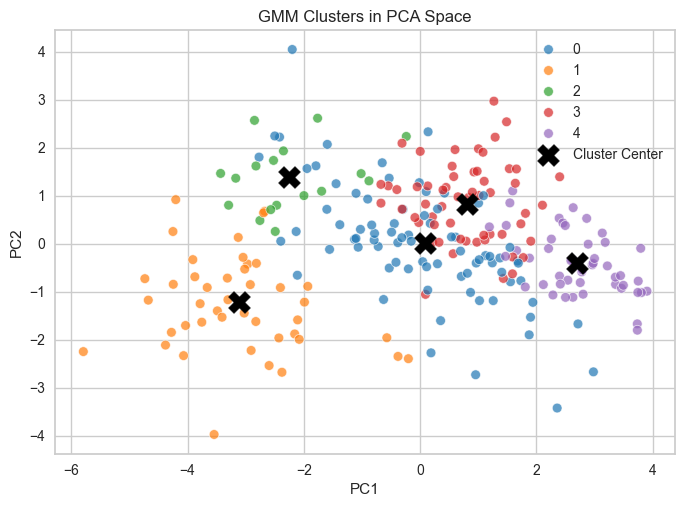

In [85]:
pca_df["gmm_cluster"] = df["gmm_cluster"]
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="gmm_cluster",
    palette="tab10",
    alpha=0.7
)

plt.scatter(
    gmm.means_[:,0],
    gmm.means_[:,1],
    c="black",
    s=250,
    marker="X",
    label="Cluster Center"
)

plt.title("GMM Clusters in PCA Space")
plt.legend()

plt.savefig(f"images/analysis/cluster_space.png", bbox_inches="tight", dpi=150)
plt.show()

### Driver performance indicators vs Total points
- Average Finish vs Total Points: The relationship between average finishing position and total points is probably the most intuitive performance signal in the dataset, and the clusters follow that pattern almost perfectly. As the average finishing position improves (moving toward the left side of the chart), total points increase sharply, which reflects how the modern F1 points system heavily rewards consistent top finishes. Cluster 1 clearly dominates the top-left region with the best average finishing positions and the highest point totals, matching the interpretation of dominant or championship-caliber seasons. Cluster 2 sits just to the right of that group with slightly worse average finishes but still strong point totals, representing competitive seasons that regularly finish in the top positions but not quite as consistently as the elite cluster. Cluster 0 spreads through the middle of the chart where average finishes fall around the midfield range and point totals are moderate, which aligns well with typical midfield driver campaigns. Finally, clusters 3 and 4 occupy the far right side with poor average finishing positions and extremely low points totals, capturing struggling or backmarker seasons where drivers rarely finish inside the points.

 - DNF Rate vs Total Points: This plot shows one of the clearest statistical relationships in the entire dataset: higher DNF rates strongly correspond to lower season point totals. In Formula 1 this relationship is almost unavoidable since failing to finish a race means scoring zero points regardless of pace. The clusters reflect this pattern clearly. Cluster 1 sits almost entirely in the low-DNF, high-points region, reinforcing the idea that it captures dominant seasons where drivers both finish races and consistently score near the front. Cluster 2 also appears in relatively low DNF regions but with slightly lower point totals, suggesting strong seasons that are competitive but not quite at championship-level dominance. Cluster 0 spreads across the mid-range of the chart where reliability becomes more variable and points totals fluctuate accordingly, which fits well with the interpretation of a midfield performance tier. Clusters 3 and especially 4 occupy the high-DNF and low-points region, representing struggling seasons where mechanical issues, crashes, or uncompetitive cars severely limit a driver’s ability to score points.

- Top 10 rate vs Total Points: The relationship between top-10 finish rate and total season points is almost exactly what you would expect given how the Formula 1 points system works. Drivers who finish inside the top ten more frequently accumulate points much faster across the season, and that pattern shows up clearly in the clusters. Cluster 1 dominates the right portion of the chart with extremely high points totals and top-10 rates that approach one, meaning those drivers finished in the points almost every race. This aligns well with the idea that Cluster 1 represents the strongest seasons in the dataset, where drivers consistently ran at the front and rarely missed scoring opportunities. Cluster 2 sits slightly below that group with very strong but slightly lower top-10 rates and somewhat fewer points, suggesting competitive seasons where drivers were frequently in the points but not quite as dominant. Cluster 0 spreads through the middle of the plot with moderate top-10 rates and moderate point totals, which fits the profile of midfield drivers who occasionally score points but lack the consistency to do so every race. Meanwhile Clusters 3 and 4 sit near the bottom of the chart with very low top-10 rates and minimal points totals, capturing seasons where drivers rarely finished inside the scoring positions, often due to weaker cars or reliability issues.

- Finish Volatility vs Total Points: This plot highlights how consistency during a season relates to overall success, and the cluster structure reflects that pretty well. Cluster 1 clearly dominates the upper part of the chart with very high point totals, which aligns with the idea that this cluster captures the strongest seasons in the dataset. Interestingly, those seasons often sit in a moderate volatility range rather than the absolute lowest. In Formula 1 terms this makes sense because even championship-level drivers still have some variation in results across a long season. Cluster 2 appears just below that group, representing strong but slightly less dominant seasons where drivers still score heavily but with somewhat more variation in finishing positions. Meanwhile clusters 3 and 4 concentrate near the bottom of the chart with very low points totals, reflecting struggling or backmarker seasons where finishing positions fluctuate but rarely produce strong results. Cluster 0 spreads across the middle of the plot, which fits the interpretation of a midfield group where drivers score occasional points but don’t consistently challenge at the front.

- DVT vs Total Points: The relationship between DVT and total points shows a similar performance gradient across clusters, although the separation is less pronounced than with other metrics. Cluster 1 again occupies the high-points region, reinforcing the idea that it represents the strongest seasons in the dataset. Cluster 2 sits somewhat below it but still clearly above the midfield groups, which supports the interpretation of a competitive but slightly less dominant performance tier. Cluster 0 spreads across the middle of the plot with moderate point totals, matching the pattern expected from midfield drivers who occasionally score strong finishes but lack the consistency or pace to accumulate points at the same rate as top contenders. Clusters 3 and 4 remain concentrated near the bottom of the chart with very low point totals, reflecting seasons where results rarely translate into meaningful championship points. Overall the distribution suggests that DVT contributes to the broader performance profile captured by the model, but it doesn’t separate the clusters as strongly as reliability or average finishing position.



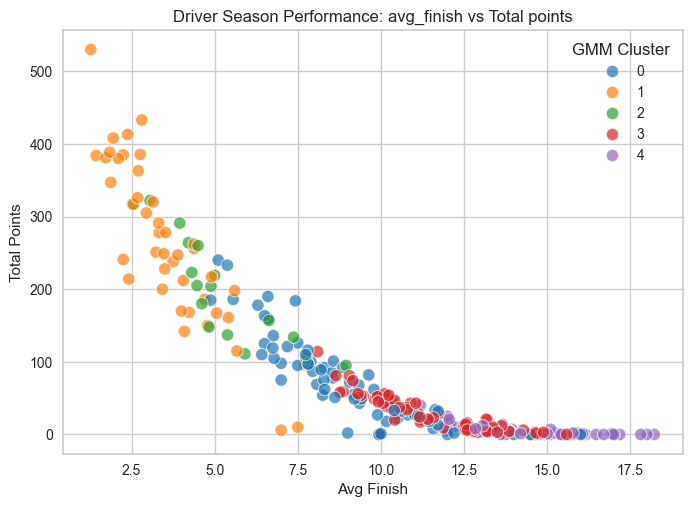

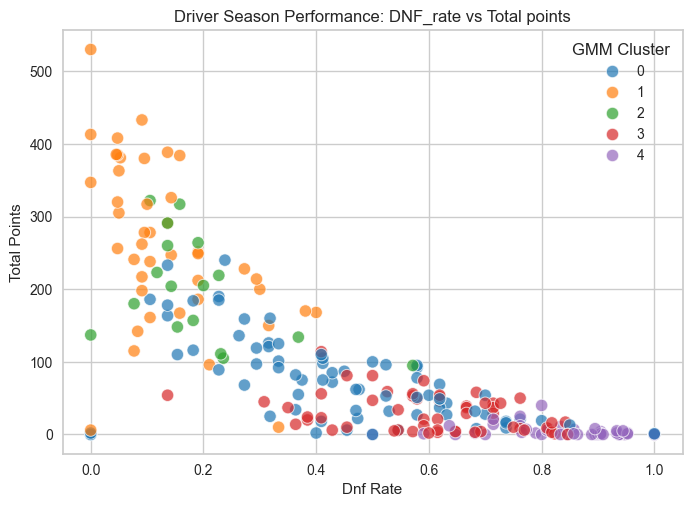

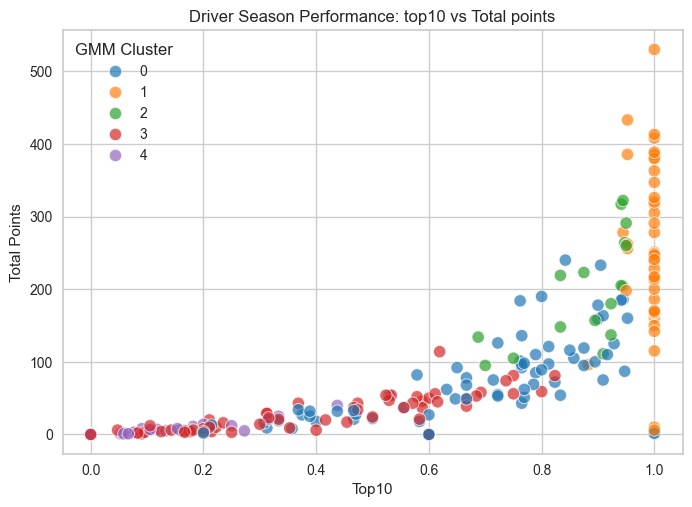

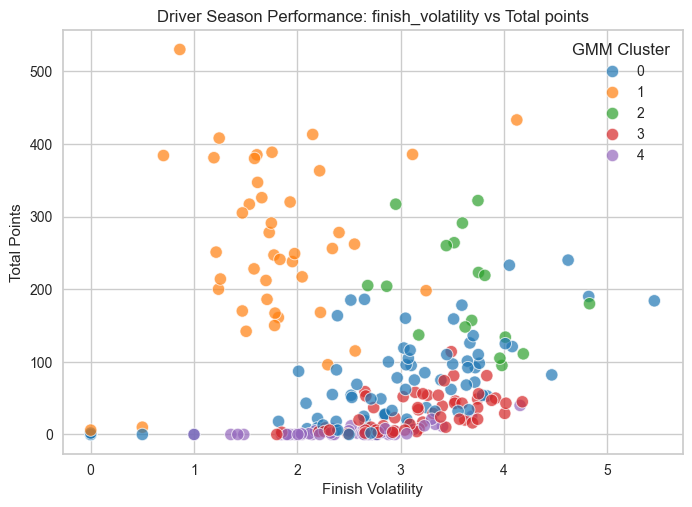

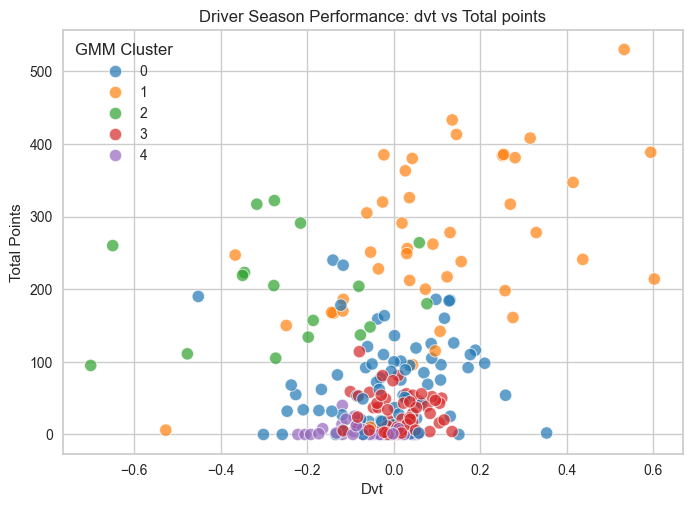

In [87]:
for var in ["avg_finish","DNF_rate","top10", "finish_volatility", "dvt"]:
    sns.scatterplot(
        data=df,
        x=var,
        y="total_points",
        hue="gmm_cluster",
        palette="tab10",
        alpha=0.7,   # makes overlapping points visible
        s=80         # marker size
    )
    plt.title(f"Driver Season Performance: {var} vs Total points")
    plt.xlabel(var.replace("_"," ").title())
    plt.ylabel("Total Points")
    plt.legend(title="GMM Cluster")
    plt.savefig(f"images/analysis/{var}_cluster_scatter.png", bbox_inches="tight", dpi=150)
    plt.show()

### Point distribution by cluster
The points distribution across clusters makes the overall performance hierarchy very clear. Cluster 1 stands out immediately with the widest and highest range of points, stretching from roughly 200 to well above 500. These are clearly the strongest driver seasons in the dataset, where drivers consistently finished near the front and accumulated points throughout the year. Cluster 2 sits just below it, ranging roughly from 150 to around 300 points, which suggests competitive seasons that were strong but not quite at the same level of dominance. Cluster 0 falls into a more typical midfield range, mostly between 0 and about 100 points, reflecting drivers who occasionally scored but lacked the consistency or car performance to challenge regularly at the front. Cluster 3 is even more compressed, generally staying between 0 and about 50 points, which indicates struggling seasons where points finishes were rare. Finally, Cluster 4 is extremely thin and sits almost entirely near zero points, capturing true backmarker seasons where drivers rarely scored at all. Overall the distribution reinforces the idea that the clustering is capturing a clear performance ladder across driver seasons.

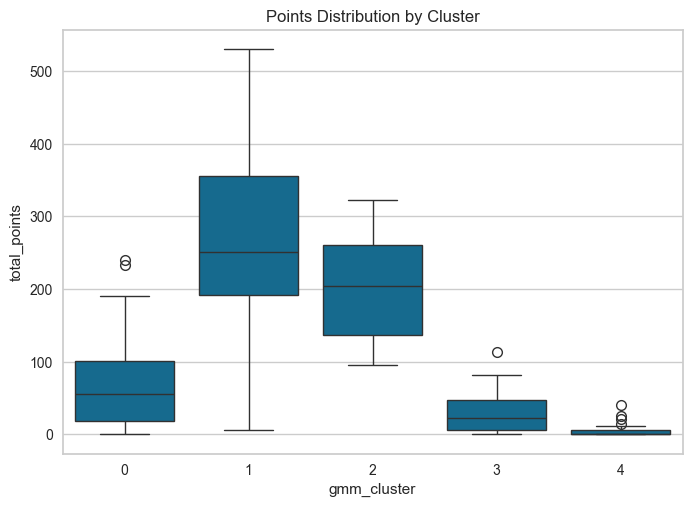

In [81]:
sns.boxplot(
    data=df,
    x="gmm_cluster",
    y="total_points"
)

plt.title("Points Distribution by Cluster")
plt.savefig(f"images/analysis/cluster_boxplot.png", bbox_inches="tight", dpi=150)
plt.show()

### Standardized Average Performance Metrics by Cluster

Looking at the standardized performance metrics helps clarify what actually defines each cluster beyond just points totals. Cluster 1 shows extremely high values for total points and top-10 rate, which matches the interpretation that these seasons represent the most competitive drivers who consistently finished in the points. At the other end of the spectrum, Clusters 3 and 4 show much higher average finishing positions, meaning drivers in those groups were typically finishing further down the order. That aligns with the very low points totals seen in the earlier plots. The middle clusters fill in the expected gradient between those extremes: Cluster 2 still performs well across most metrics but not quite at the same level as Cluster 1, while Cluster 0 sits closer to a midfield profile where drivers occasionally finish well but not consistently enough to accumulate large point totals. When all metrics are viewed together, the clusters form a very intuitive set of performance archetypes ranging from dominant seasons to struggling backmarker campaigns.

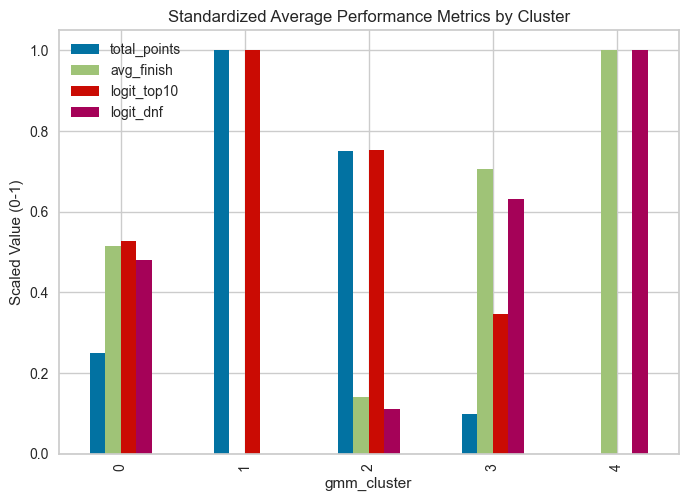

In [80]:
from sklearn.preprocessing import MinMaxScaler

metrics = ["total_points","avg_finish","logit_top10","logit_dnf"]
cluster_means = df.groupby("gmm_cluster")[metrics].mean()
scaled = cluster_means.copy()
scaled[metrics] = MinMaxScaler().fit_transform(cluster_means[metrics])

scaled.plot(kind="bar")
plt.title("Standardized Average Performance Metrics by Cluster")
plt.ylabel("Scaled Value (0-1)")
plt.savefig(f"images/analysis/cluster_performance.png", bbox_inches="tight", dpi=150)
plt.show()

### Number of Driver Seasons per GMM Cluster

Looking at how many driver seasons fall into each cluster helps give some context for how common each performance type actually is. Cluster 0 is the largest group with around 80 seasons, which suggests that the kind of performance it represents is the most typical across the dataset. These are likely the more common midfield-type seasons where drivers score some points but aren’t consistently competing at the very front. Cluster 3 and Cluster 4 also contain a substantial number of seasons, with roughly 57 and 47 respectively, indicating that struggling or low-scoring seasons are also quite frequent in Formula 1. This makes sense considering the structure of the grid, where a limited number of teams fight near the front while several drivers spend most seasons outside regular point-scoring positions. Cluster 1, which captures the strongest seasons in the dataset, is noticeably smaller with about 42 observations, reflecting how relatively rare dominant or near-dominant seasons actually are. Finally, Cluster 2 is the smallest group with only around 17 seasons, suggesting it represents a more specific performance profile that sits between the elite Cluster 1 seasons and the broader midfield group. Overall, the distribution reinforces the idea that the clusters reflect realistic performance tiers in Formula 1, with dominant seasons being much less common than midfield or lower-performing campaigns.

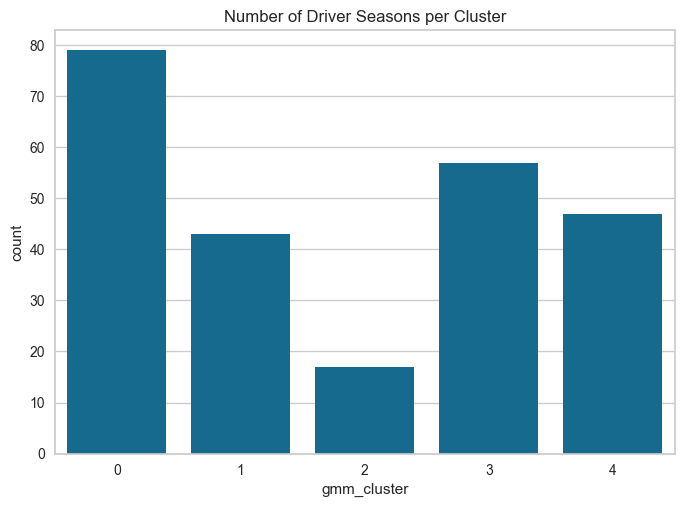

In [93]:
sns.countplot(data=df, x="gmm_cluster")
plt.title("Number of Driver Seasons per Cluster")
plt.savefig(f"images/analysis/cluster_size.png", bbox_inches="tight", dpi=150)

### Distribution of cluster confidence
The distribution of cluster confidence shows that the model is generally very certain about its assignments. The histogram is heavily concentrated near the highest confidence values, with a large spike close to 100% and a gradual decline as confidence decreases toward 50%. This indicates that most driver seasons fit very clearly into one cluster profile rather than sitting ambiguously between multiple groups. At the same time, the slow taper toward lower confidence levels is actually expected with a Gaussian Mixture Model because some seasons naturally share characteristics with more than one performance archetype. In Formula 1 terms this makes sense: not every season is clearly dominant, midfield, or backmarker. Some drivers may show a mix of strong results, inconsistent finishes, or reliability problems that place them somewhere between two cluster profiles. The fact that most observations still have very high confidence suggests the clustering is capturing real structure in the data rather than forcing arbitrary groupings.

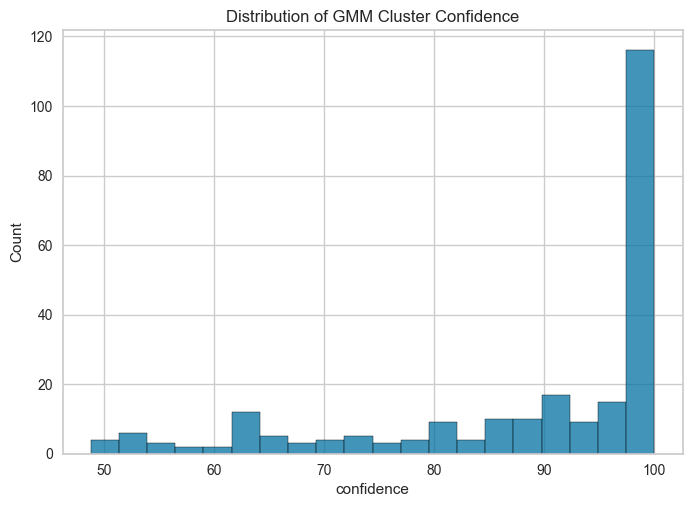

In [94]:
sns.histplot(data=df, x="confidence", bins=20)
plt.title("Distribution of GMM Cluster Confidence")
plt.savefig(f"images/analysis/gmm_distribution.png", bbox_inches="tight", dpi=150)

### Cluster Size Change Over Time

Looking at how cluster sizes change over time gives a useful perspective on how driver performance patterns evolve across seasons. Clusters 3 and 4 remain relatively flat throughout the timeline with only occasional spikes, which suggests that struggling or backmarker seasons appear fairly consistently across different eras of Formula 1. Cluster 0 shows a different pattern: it stays fairly stable until around 2018 and then begins fluctuating more noticeably from year to year. That variation likely reflects changes in midfield competitiveness, where small shifts in team performance can move drivers between scoring and non-scoring seasons. Cluster 2 shows a spike around 2014 before settling into a flatter pattern, followed by another rise around 2022, which may reflect periods where multiple drivers produced strong but not dominant seasons. Cluster 1 follows a similar pattern but without the early spike, instead fluctuating more gradually across the timeline. Overall the plot suggests that while elite and competitive seasons vary slightly across years, the general distribution of driver performance tiers remains relatively stable across modern Formula 1 seasons.

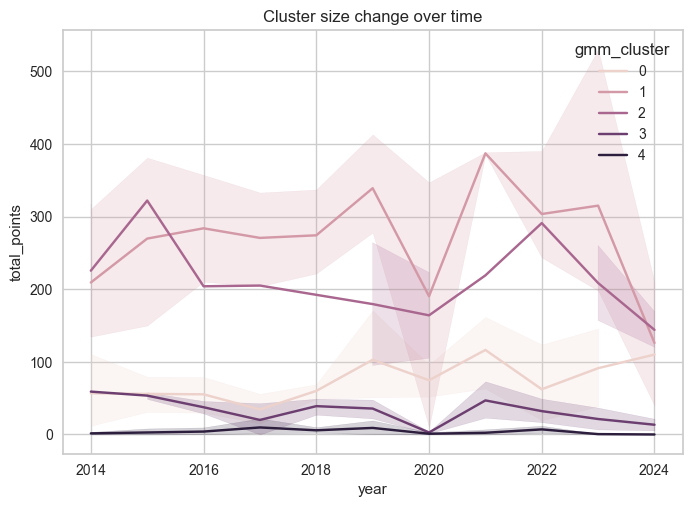

In [95]:
sns.lineplot(data=df, x="year", y="total_points", hue="gmm_cluster")
plt.title("Cluster size change over time")
plt.savefig(f"images/analysis/cluster_time.png", bbox_inches="tight", dpi=150)

## Key Insights From the Analysis

Several clear patterns emerge from the clustering results.

First, the distribution of driver seasons across clusters shows that most seasons fall into the midfield or lower-performing groups, while truly dominant seasons are relatively rare. This reflects the competitive structure of Formula 1, where only a small number of teams consistently operate at the front of the grid.

Second, the performance relationships highlight how strongly consistency drives season success. Drivers with high top-10 rates and strong average finishing positions accumulate points far more reliably, while higher DNF rates quickly push seasons into the lower-performing clusters. In other words, sustained race-to-race results matter more than occasional standout performances.

Third, the Gaussian Mixture Model assigns most driver seasons to clusters with very high confidence. This suggests that the clusters represent real statistical groupings in the data rather than arbitrary separations created by the algorithm.

Finally, looking at cluster size across seasons shows that while the number of strong or competitive seasons fluctuates slightly from year to year, the overall structure of performance tiers remains relatively stable. Formula 1 consistently produces a small group of elite seasons, a larger midfield group, and a number of struggling campaigns.

## Conclusion

This project explored how unsupervised machine learning can be used to identify underlying performance patterns in Formula 1 driver seasons. By combining PCA for dimensionality reduction with Gaussian Mixture clustering, driver seasons were grouped based on their statistical performance profiles rather than predefined labels.

The results reveal that driver performance naturally separates into distinct tiers, ranging from dominant seasons with high point totals and strong finishing consistency to seasons where drivers rarely score points. These groupings align closely with how fans and analysts intuitively describe the competitive structure of Formula 1.

More broadly, the analysis demonstrates how clustering techniques can uncover meaningful structure in sports data and provide a data-driven way to describe different types of competitive performance across seasons.

In [42]:
df.to_csv("drivers_clustered.csv", index=False)